In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
 
import mlflow
import mlflow.xgboost
 
import warnings
warnings.filterwarnings("ignore")

/home/mai/notebooks/final_thesis/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# Config
# ─────────────────────────────────────────────────────────────────────────────
 
os.chdir('/home/mai/notebooks/final_thesis/')
 
PLOT_DIR = './plots'
os.makedirs(PLOT_DIR, exist_ok=True)
 
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif':  ['DejaVu Serif'],
    'mathtext.fontset': 'stix',
})

In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# Load best XGBoost model from MLflow
# ─────────────────────────────────────────────────────────────────────────────
 
experiment_name = 'xgb_optuna_tuning'
exp = mlflow.get_experiment_by_name(experiment_name)
runs = mlflow.search_runs(
    experiment_ids=[exp.experiment_id],
    filter_string="params.feat_augment = 'True'",
    order_by=["metrics.ap DESC"],
    max_results=1
)
 
best_run = runs.iloc[0]
best_run_id = best_run.run_id
print(f"Best run: {best_run_id}")
print(f"Best AP: {best_run['metrics.ap']:.4f}")
 
model = mlflow.xgboost.load_model(f"runs:/{best_run_id}/model")

Best run: 944a58b8183c4f72abd9c5c699050c57
Best AP: 0.3646


In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# Extract feature importance
# ─────────────────────────────────────────────────────────────────────────────
 
importance = model.get_booster().get_score(importance_type='gain')
importance_df = pd.DataFrame({
    'feature': list(importance.keys()),
    'importance': list(importance.values())
}).sort_values(by='importance', ascending=False)
 
# Assign feature names
default_features = [f'Feature {i}' for i in range(17)]
additional_features = [
    'Out Degree', 'In Degree', 'Degree Ratio',
    'Recency', 'Burst Ratio', 'Mean Timespan', 'Std Timespan'
]
feature_names = default_features + additional_features
feature_name_map = {str(i): name for i, name in enumerate(feature_names)}
 
importance_df['feature_name'] = importance_df['feature'].map(feature_name_map)
importance_df['feature_idx'] = importance_df['feature'].astype(int)
importance_df['is_augmented'] = importance_df['feature_idx'] >= 17
 
# Normalise importance to percentage for readability
importance_df['importance_pct'] = (
    importance_df['importance'] / importance_df['importance'].sum() * 100
)

In [24]:
# ─────────────────────────────────────────────────────────────────────────────
# Plot
# ─────────────────────────────────────────────────────────────────────────────
 
# Sort ascending for horizontal bar plot (top feature at top)
plot_df = importance_df.sort_values('importance_pct', ascending=True)
 
fig, ax = plt.subplots(figsize=(8, 6))
 
# Color by feature type
colors = [
    '#ff7f0e' if aug else '#1f77b4'
    for aug in plot_df['is_augmented']
]
 
bars = ax.barh(
    y=range(len(plot_df)),
    width=plot_df['importance_pct'],
    color=colors,
    edgecolor='none',
    height=0.7,
)
 
# Y-axis: feature names
ax.set_yticks(range(len(plot_df)))
ax.set_yticklabels(plot_df['feature_name'], fontsize=12)
 
# X-axis
ax.set_xlabel('Relative Importance (%)', fontsize=14)
 
# Value labels on bars
for i, (val, name) in enumerate(zip(plot_df['importance_pct'], plot_df['feature_name'])):
    ax.text(val + 0.3, i, f'{val:.1f}%', va='center', fontsize=12)
 
# Extend x-axis slightly to fit labels
ax.set_xlim(0, plot_df['importance_pct'].max() * 1.15)
 
# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#1f77b4', label='Default features'),
    Patch(facecolor='#ff7f0e', label='Augmented features'),
]
ax.legend(
    handles=legend_elements,
    loc='lower right',
    fontsize=12,
    frameon=False,
)
 
# Clean up
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='x', labelsize=12)
 
fig.tight_layout()
 
path_out = os.path.join(PLOT_DIR, 'feature_importance.png')
fig.savefig(path_out, dpi=300, bbox_inches='tight')
print(f'Saved: {path_out}')
plt.close(fig)

Saved: ./plots/feature_importance.png


In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# Print summary
# ─────────────────────────────────────────────────────────────────────────────
 
aug_total = importance_df.loc[importance_df['is_augmented'], 'importance_pct'].sum()
def_total = importance_df.loc[~importance_df['is_augmented'], 'importance_pct'].sum()
 
print(f'\nAugmented features: {aug_total:.1f}% of total importance')
print(f'Default features:   {def_total:.1f}% of total importance')
print(f'\nTop 5 features:')
for _, row in importance_df.head(5).iterrows():
    tag = '(aug)' if row['is_augmented'] else '(def)'
    print(f'  {row["feature_name"]:>15s} {tag}: {row["importance_pct"]:.1f}%')


Augmented features: 80.7% of total importance
Default features:   19.3% of total importance

Top 5 features:
    Mean Timespan (aug): 29.5%
        In Degree (aug): 20.7%
      Burst Ratio (aug): 10.5%
          Recency (aug): 7.6%
     Std Timespan (aug): 6.9%


In [ ]:
# import shap
# from src.namespaces import DA

# def load_data(data_path, feat_augment=True):
#     data = np.load(os.path.join(data_path, 'dgraphfin_processed.npz'))
#     # train
#     X_train = pd.DataFrame(data['x_train'])
#     y_train = pd.DataFrame(data['y_train'])
#     # val
#     X_val = pd.DataFrame(data['x_val'])
#     y_val = pd.DataFrame(data['y_val'])
#     # test
#     X_test = pd.DataFrame(data['x_test'])
#     y_test = pd.DataFrame(data['y_test'])

#     if not feat_augment:
#         X_train = X_train.iloc[:, :17]
#         X_val = X_val.iloc[:, :17]
#         X_test = X_test.iloc[:, :17]
#     return X_train, X_val, X_test, y_train, y_val, y_test


# _, _, X_test, _, _, y_test = load_data(
#     data_path=DA.paths.output_data_ml, feat_augment=True
# )

# explainer = shap.TreeExplainer(model)
# shap_values = explainer.shap_values(X_test)

# shap.summary_plot(shap_values, X_test, feature_names=list(feature_name_map.values()))

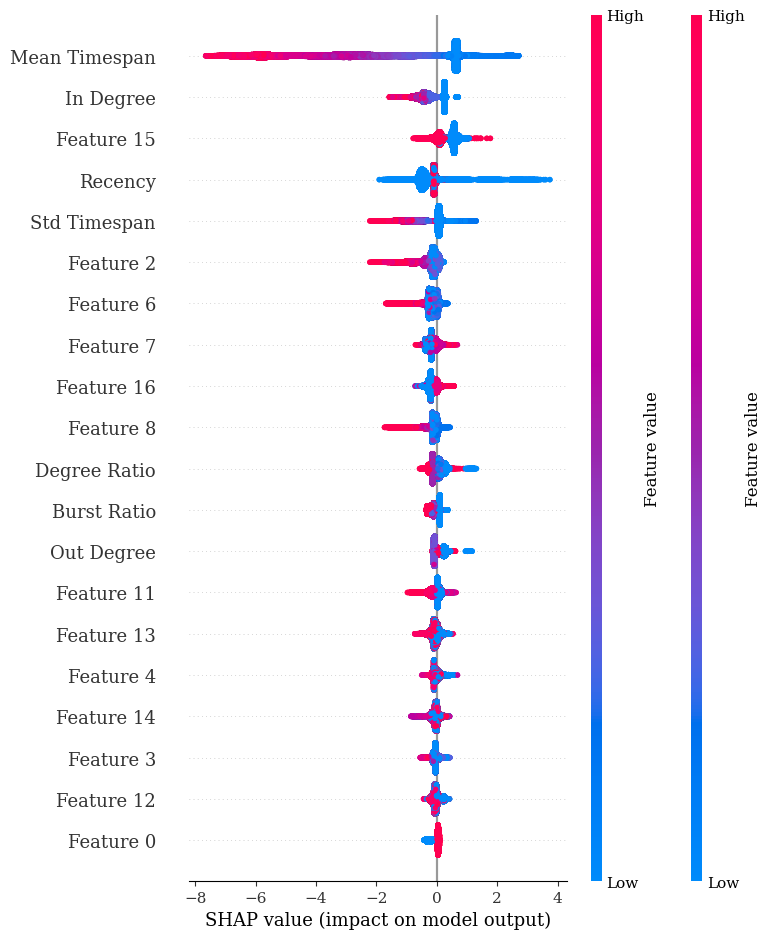

In [ ]:
# %matplotlib inline

# shap.summary_plot(shap_values, X_test, feature_names=list(feature_name_map.values()), show=True)
# plt.show()